In [275]:
import pandas as pd                                                               # data analysis and manipulation
import numpy as np                                                                # numerical computing
from scipy import stats                                                           # statistical functions
from sklearn.metrics import mean_squared_error                                    # model evaluation
import matplotlib.pyplot as plt                                                   # data visualization
import seaborn as sns                                                             # statistical data visualization
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score                         # splitting data
from sklearn.compose import make_column_transformer, ColumnTransformer            # feature engineering
from sklearn.pipeline import Pipeline, make_pipeline                              # building ML pipelines
from sklearn.impute import SimpleImputer                                          # handling missing values
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder   # data preprocessing
from sklearn.linear_model import LinearRegression, Ridge                          # regression models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor,StackingRegressor                               # ensemble model
from xgboost import XGBRegressor                                                  # extreme gradient boosting models
import lightgbm as lgbm                                                           # light gradient boosting models 



import warnings                                                                   # handling warnings
warnings.filterwarnings('ignore')                                                 # ignore warnings for cleaner output      


In [276]:
housing_data = pd.read_csv(r'C:\Users\ADMIN\Downloads\Project data sets\python\.venv\projects\mini projects\data.csv')           # load dataset


In [277]:
housing_data.head()        # display first few rows of the dataset

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [278]:
housing_data.tail()       # display last few rows of the dataset

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [279]:
housing_data.info()        # get dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [280]:
housing_data.columns            # display column names

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [281]:
housing_data.describe()           # statistical summary of numerical features

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [282]:
housing_data.duplicated().sum()      # check for duplicate rows

np.int64(0)

In [283]:
housing_data.isnull().sum()    # check for missing values

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [284]:
housing_data.dtypes[housing_data.dtypes != 'object'] # numerical feature data types

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

In [285]:
housing_data.dtypes[housing_data.dtypes == 'object']  # categorical feature data types

MSZoning         object
Street           object
Alley            object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
ExterQual        object
ExterCond        object
Foundation       object
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Heating          object
HeatingQC        object
CentralAir       object
Electrical       object
KitchenQual      object
Functional       object
FireplaceQu      object
GarageType       object
GarageFinish     object
GarageQual       object
GarageCond       object
PavedDrive       object
PoolQC           object
Fence            object
MiscFeature      object
SaleType        

In [286]:
housing_data.select_dtypes(include=['object']).shape[1]  # unique values in categorical features

43

In [287]:
housing_data.select_dtypes(include=['int64','float64']).shape[1]

38

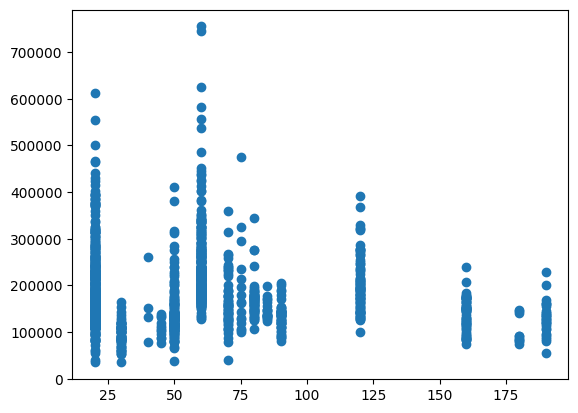

In [288]:
plt.scatter(x = 'MSSubClass',y = 'SalePrice', data = housing_data)  # visualize MSSubClass vs SalePrice

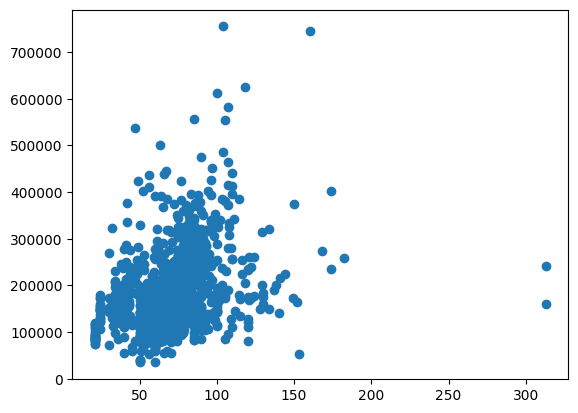

In [289]:
plt.scatter(x = 'LotFrontage',y = 'SalePrice', data = housing_data) # visualize LotFrontage vs SalePrice

In [290]:
housing_data.query("LotFrontage  > 300")   # identify outliers in LotFrontage
# drop 935,1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


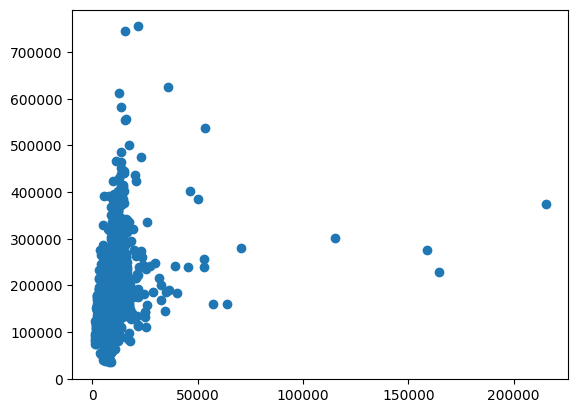

In [291]:
plt.scatter(x = 'LotArea',y = 'SalePrice', data = housing_data) # visualize LotArea vs SalePrice

In [292]:
housing_data.query('LotArea > 55000')    # identify outliers in LotArea
# 250,314,336,452,707
# maybe 1397

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,NaN,159000,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,Shed,700,8,2008,WD,Normal,228950
451,452,20,RL,62.0,70761,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,280000
706,707,20,RL,NaN,115149,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,302000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
1396,1397,20,RL,NaN,57200,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,160000


In [293]:
pd.Series(stats.zscore(housing_data['LotArea'])).sort_values().tail(10)     # identify outliers using Z-score

384      4.268474
457      4.280500
769      4.308262
1396     4.678682
1298     5.348867
451      6.037793
706     10.486449
249     14.881285
335     15.448542
313     20.518273
dtype: float64

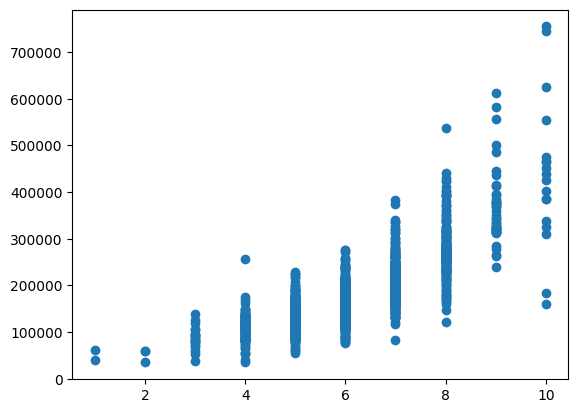

In [294]:
plt.scatter(x = 'OverallQual',y = 'SalePrice', data = housing_data) # visualize OverallQual vs SalePrice

In [295]:
housing_data.query('OverallQual == 10')    # identify outliers in OverallQual
# 524

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
58,59,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
224,225,20,RL,103.0,13472,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,386250
389,390,60,RL,96.0,12474,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2008,New,Partial,426000
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000
515,516,20,RL,94.0,12220,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,New,Partial,402861
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
591,592,60,RL,97.0,13478,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,ConLI,Normal,451950
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


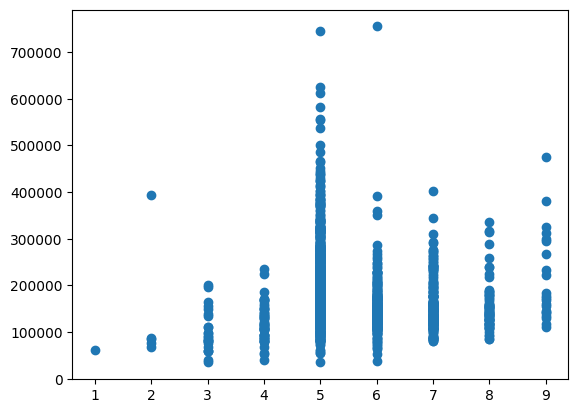

In [296]:
plt.scatter(x = 'OverallCond',y = 'SalePrice', data = housing_data) # visualize OverallCond vs SalePrice

In [297]:
housing_data.query('OverallCond == 2')    # identify outliers in OverallCond
#379

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
88,89,50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
250,251,30,RL,55.0,5350,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdWo,Shed,450,5,2010,WD,Normal,76500
378,379,20,RL,88.0,11394,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,New,Partial,394432
398,399,30,RM,60.0,8967,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Abnorml,67000
676,677,70,RM,60.0,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,87000


In [298]:
housing_data.query('OverallCond == 5 & SalePrice > 700000')    # identify outliers in OverallCond
# 1183

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [299]:
housing_data.query('OverallCond == 6 & SalePrice > 700000')    # identify outliers in OverallCond
# 692

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


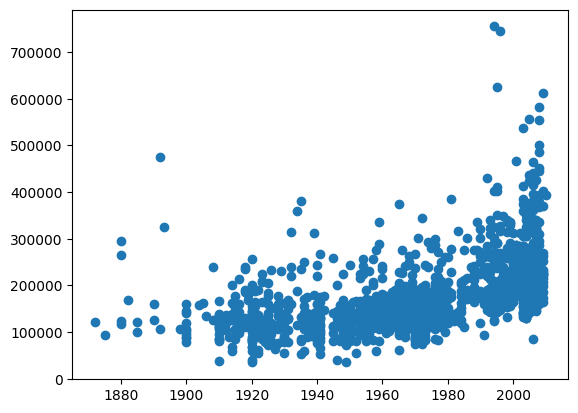

In [300]:
plt.scatter(x = 'YearBuilt',y = 'SalePrice', data = housing_data) # visualize YearBuilt vs SalePrice

In [301]:
housing_data.query('YearBuilt < 1900 & SalePrice > 400000')   # identify outliers in YearBuilt
# 186

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000


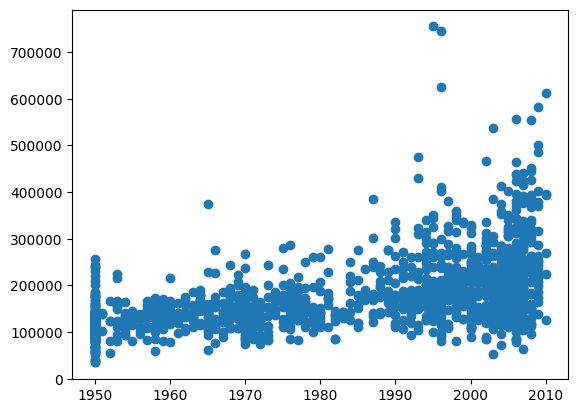

In [302]:
plt.scatter(x = 'YearRemodAdd',y = 'SalePrice', data = housing_data) # visualize YearRemodAdd vs SalePrice

In [303]:
housing_data.query('YearRemodAdd < 1970 & SalePrice > 300000')   # identify outliers in YearRemodAdd
#314    

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000


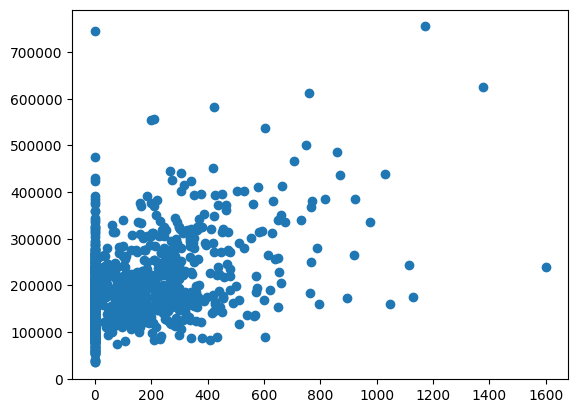

In [304]:
plt.scatter(x = 'MasVnrArea',y = 'SalePrice', data = housing_data) # visualize MasVnrArea vs SalePrice  

In [305]:
housing_data.query('MasVnrArea >1500')   # identify outliers in MasVnrArea
#298

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
297,298,60,FV,66.0,7399,Pave,Pave,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,239000


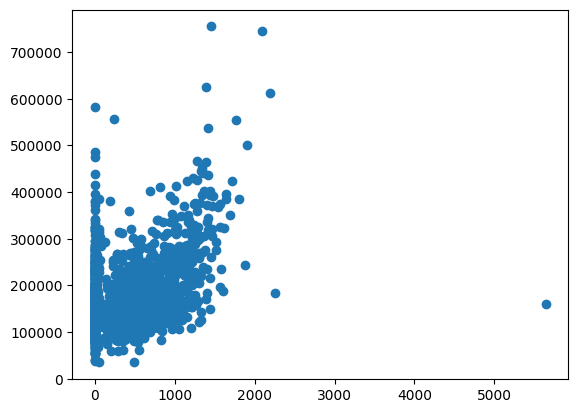

In [306]:
plt.scatter(x = 'BsmtFinSF1',y = 'SalePrice', data = housing_data) # visualize BsmtFinSF1 vs SalePrice

In [307]:
housing_data.query('BsmtFinSF1 > 3000')   # identify outliers in BsmtFinSF1
#1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


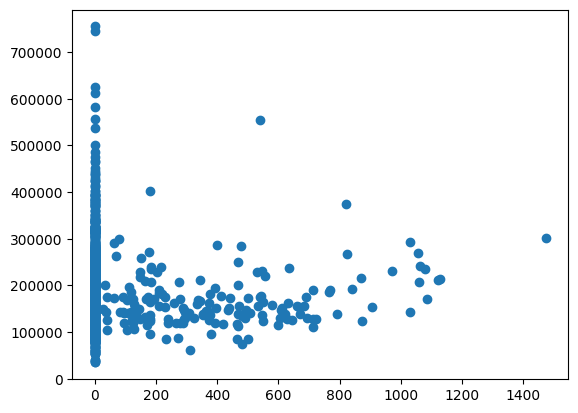

In [308]:
plt.scatter(x = 'BsmtFinSF2',y = 'SalePrice', data = housing_data)  # visualize BsmtFinSF2 vs SalePrice

In [309]:
housing_data.query('BsmtFinSF2 > 400 & SalePrice > 500000')   # identify outliers in BsmtFinSF2
#441

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000


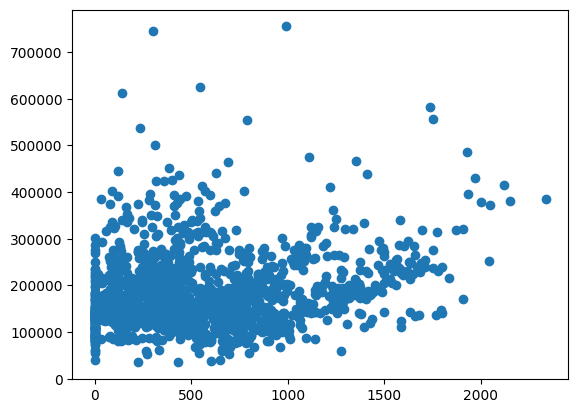

In [310]:
plt.scatter(x = 'BsmtUnfSF',y = 'SalePrice', data = housing_data)   # visualize BsmtUnfSF vs SalePrice

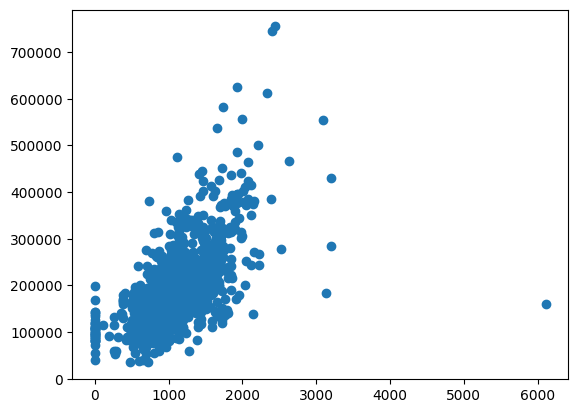

In [311]:
plt.scatter(x = 'TotalBsmtSF',y = 'SalePrice', data = housing_data)  # visualize TotalBsmtSF vs SalePrice

In [312]:
housing_data.query('TotalBsmtSF >  5000')    # identify outliers in TotalBsmtSF  
#1299 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


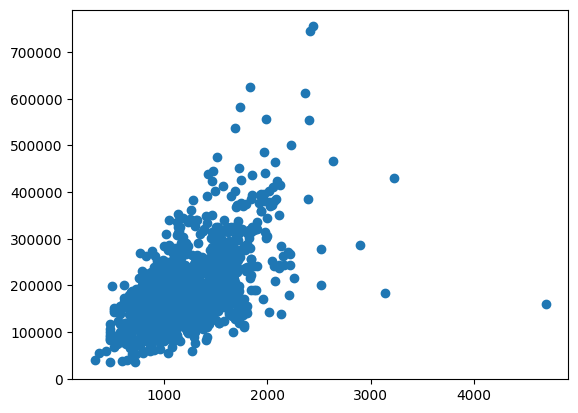

In [313]:
plt.scatter(x = '1stFlrSF',y = 'SalePrice', data = housing_data)        # visualize 1stFlrSF vs SalePrice

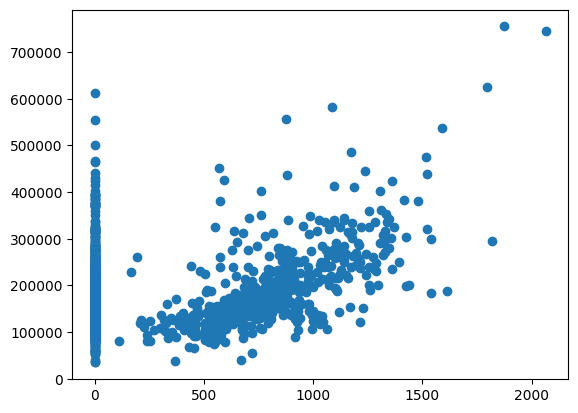

In [314]:
plt.scatter(x = '2ndFlrSF',y = 'SalePrice', data = housing_data)    # visualize 2ndFlrSF vs SalePrice

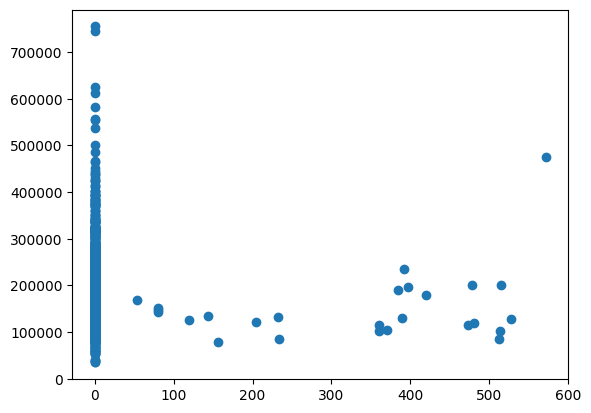

In [315]:
plt.scatter(x = 'LowQualFinSF',y = 'SalePrice', data = housing_data)    # visualize LowQualFinSF vs SalePrice

In [316]:
housing_data.query('LowQualFinSF > 500')   # identify outliers in LowQualFinSF
#186


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
88,89,50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
170,171,50,RM,NaN,12358,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,128500
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000
1009,1010,50,RL,60.0,6000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,102000


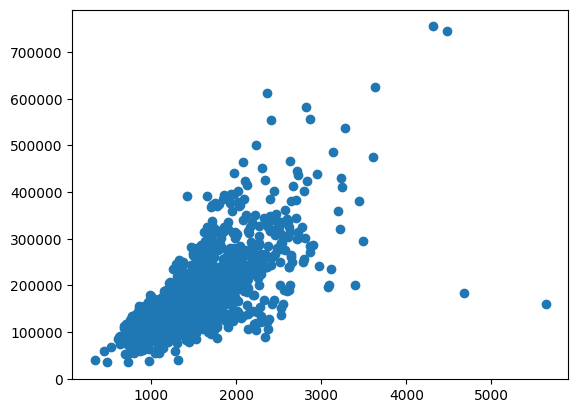

In [317]:
plt.scatter(x = 'GrLivArea',y = 'SalePrice', data = housing_data)   # visualize GrLivArea vs SalePrice

In [318]:
housing_data.query('GrLivArea > 4400')   # identify outliers in GrLivArea
#524,1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


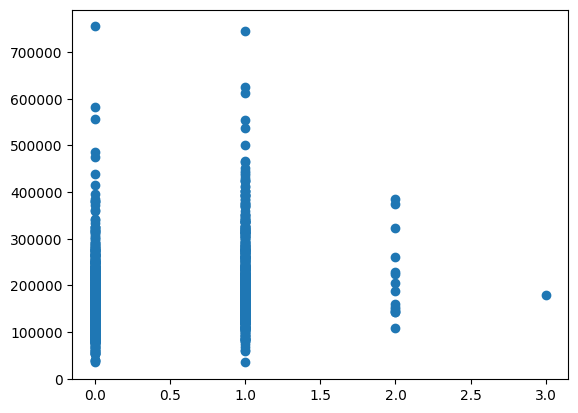

In [319]:
plt.scatter(x = 'BsmtFullBath',y = 'SalePrice', data = housing_data)    # visualize BsmtFullBath vs SalePrice

In [320]:
housing_data.query('BsmtFullBath == 3')   # identify outliers in BsmtFullBath
#739

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
738,739,90,RL,60.0,10800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Alloca,179000


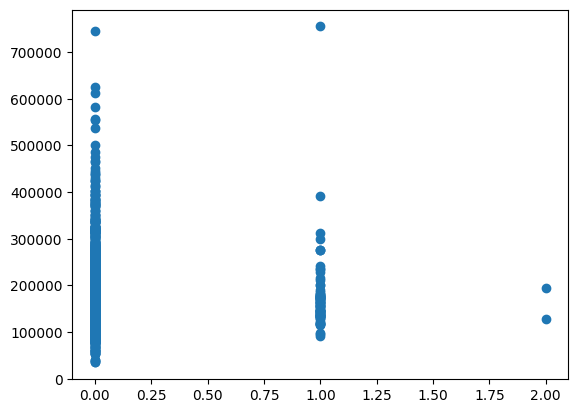

In [321]:
plt.scatter(x = 'BsmtHalfBath',y = 'SalePrice', data = housing_data) # visualize BsmtHalfBath vs SalePrice

In [322]:
pd.Series(stats.zscore(housing_data['BsmtHalfBath'])).unique()  # check unique z-scores in BsmtHalfBath

array([-0.24106104,  3.94880935,  8.13867973])

In [323]:
housing_data.query('BsmtHalfBath == 2')   # identify outliers in BsmtHalfBath
#598,955

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
597,598,120,RL,53.0,3922,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2007,New,Partial,194201
954,955,90,RL,35.0,9400,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,AdjLand,127500


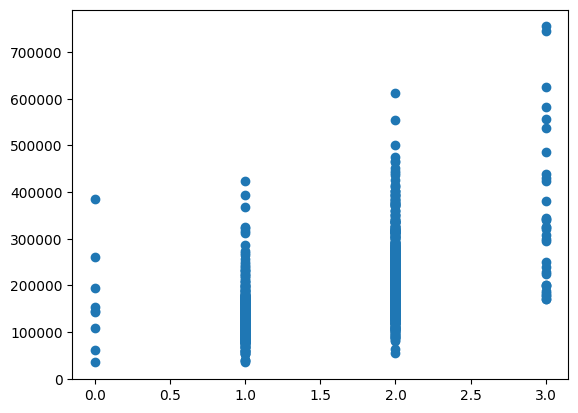

In [324]:
plt.scatter(x = 'FullBath',y = 'SalePrice', data = housing_data)   # visualize FullBath vs SalePrice                 

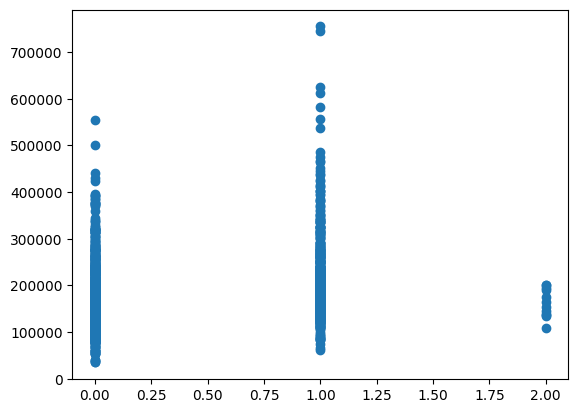

In [325]:
plt.scatter(x = 'HalfBath',y = 'SalePrice', data = housing_data) # visualize HalfBath vs SalePrice     

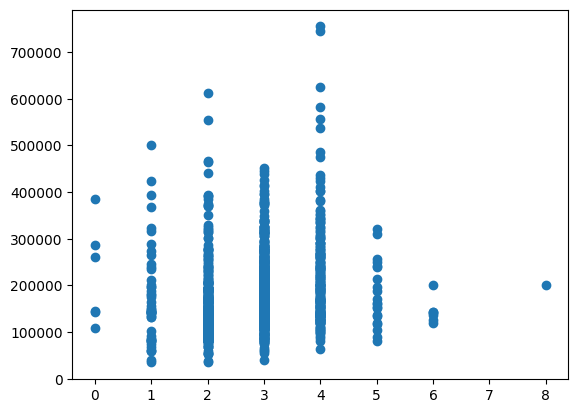

In [326]:
plt.scatter(x = 'BedroomAbvGr',y = 'SalePrice', data = housing_data)  # visualize BedroomAbvGr vs SalePrice           

In [327]:
housing_data.query('BedroomAbvGr == 8')   # identify outliers in BedroomAbvGr
#636

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000


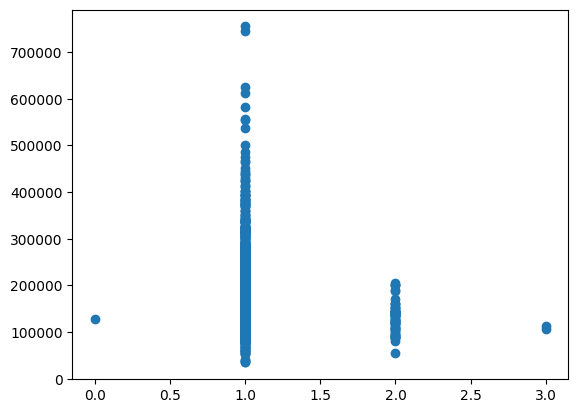

In [328]:
plt.scatter(x = 'KitchenAbvGr',y = 'SalePrice', data = housing_data)  # visualize KitchenAbvGr vs SalePrice

In [329]:
housing_data.query('KitchenAbvGr == 3')   # identify outliers in KitchenAbvGr 
#49,810

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
48,49,190,RM,33.0,4456,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,New,Partial,113000
809,810,75,RM,90.0,8100,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,11,2009,WD,Normal,106000


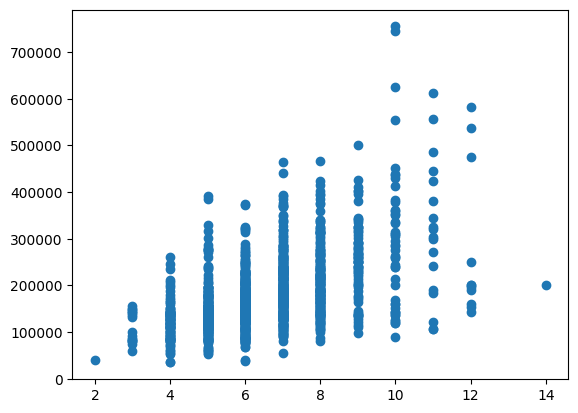

In [330]:
plt.scatter(x = 'TotRmsAbvGrd',y = 'SalePrice', data = housing_data)    # visualize TotRmsAbvGrd vs SalePrice

In [331]:
housing_data.query('TotRmsAbvGrd == 14')
#636

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000


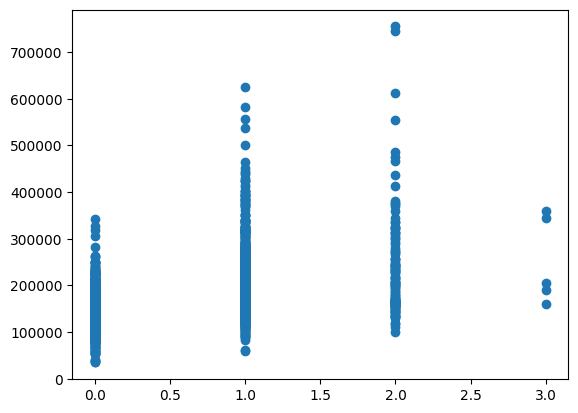

In [332]:
plt.scatter(x = 'Fireplaces',y = 'SalePrice', data = housing_data)   # visualize Fireplaces vs SalePrice

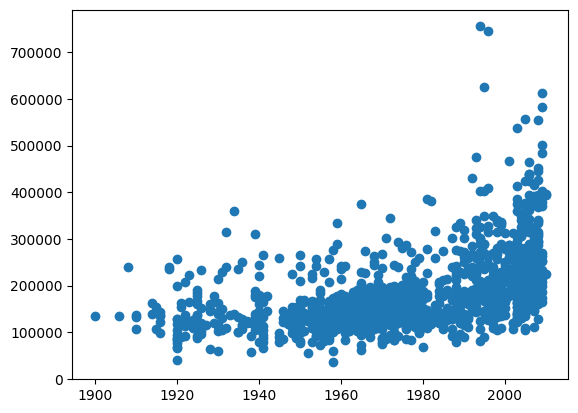

In [333]:
plt.scatter(x = 'GarageYrBlt',y = 'SalePrice', data = housing_data) # visualize GarageYrBlt vs SalePrice

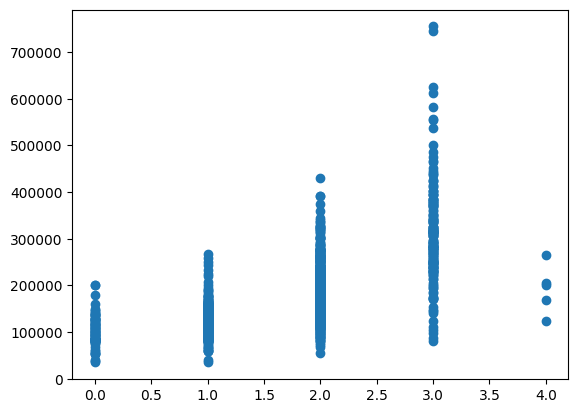

In [334]:
plt.scatter(x = 'GarageCars',y = 'SalePrice', data = housing_data) # visualize GarageCars vs SalePrice

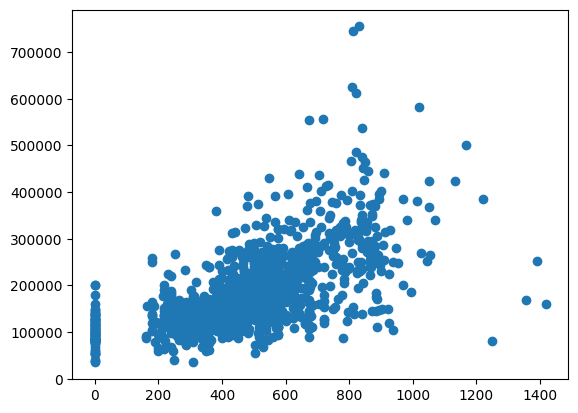

In [335]:
plt.scatter(x = 'GarageArea',y = 'SalePrice', data = housing_data) # visualize GarageArea vs SalePrice

In [336]:
housing_data.query('GarageArea > 1200')   # identify outliers in GarageArea
# 1062,1191

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
581,582,20,RL,98.0,12704,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,New,Partial,253293
825,826,20,RL,114.0,14803,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,New,Partial,385000
1061,1062,30,C (all),120.0,18000,Grvl,NaN,Reg,Low,AllPub,...,0,NaN,NaN,Shed,560,8,2008,ConLD,Normal,81000
1190,1191,190,RL,NaN,32463,Pave,NaN,Reg,Low,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,168000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


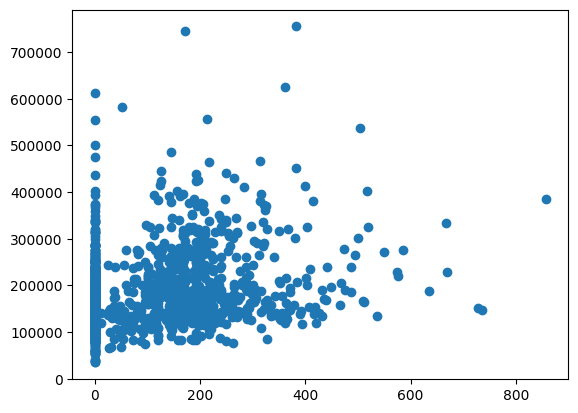

In [337]:
plt.scatter(x = 'WoodDeckSF',y = 'SalePrice', data = housing_data) # visualize WoodDeckSF vs SalePrice

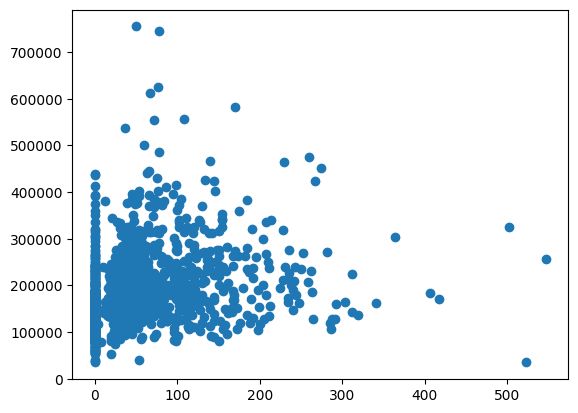

In [338]:
plt.scatter(x = 'OpenPorchSF',y = 'SalePrice', data = housing_data) # visualize OpenPorchSF vs SalePrice    

In [339]:
housing_data.query('OpenPorchSF > 500')   # identify outliers in OpenPorchSF
# 496

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
495,496,30,C (all),60.0,7879,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,11,2009,WD,Abnorml,34900
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
1328,1329,50,RM,60.0,10440,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,1150,6,2008,WD,Normal,256000


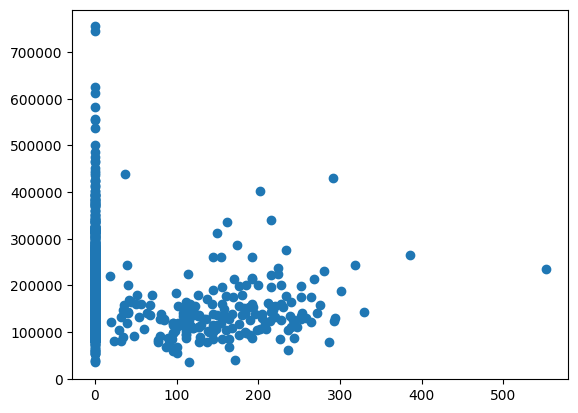

In [340]:
plt.scatter(x = 'EnclosedPorch',y = 'SalePrice', data = housing_data) # visualize EnclosedPorch vs SalePrice

In [341]:
housing_data.query('EnclosedPorch > 500')   # identify outliers in EnclosedPorch
# 198

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
197,198,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,AllPub,...,512,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000


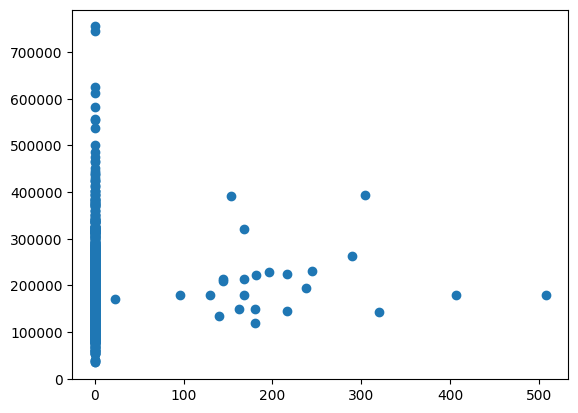

In [342]:
plt.scatter(x = '3SsnPorch',y = 'SalePrice', data = housing_data) # visualize 3SsnPorch vs SalePrice

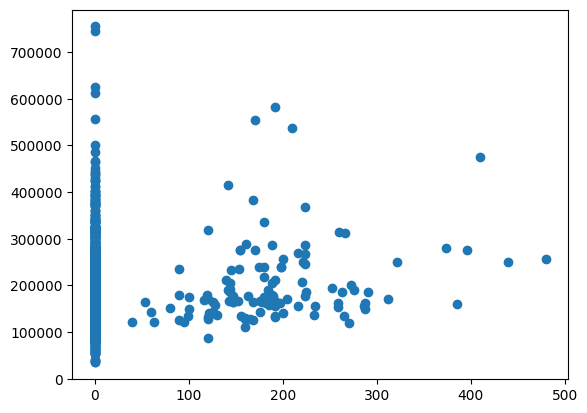

In [343]:
plt.scatter(x = 'ScreenPorch',y = 'SalePrice', data = housing_data) # visualize ScreenPorch vs SalePrice

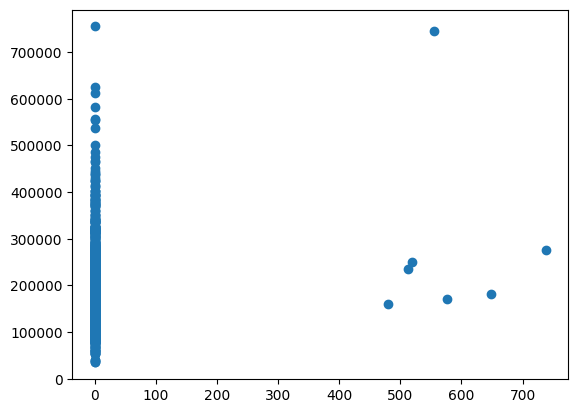

In [344]:
plt.scatter(x = 'PoolArea',y = 'SalePrice', data = housing_data) # visualize PoolArea vs SalePrice

In [345]:
values = [598, 955, 935, 1299, 250, 314, 336, 452, 707, 1397, 524, 379, 1183, 692, 186, 314, 298, 1299, 441, 1299, 524, 1299, 739, 598, 955, 636, 49, 810, 636, 1062, 1191, 496, 198]

In [346]:
drop_rows = len(values)
drop_rows

33

In [347]:
drop_keys = list(dict.fromkeys(values))
drop_keys

[598,
 955,
 935,
 1299,
 250,
 314,
 336,
 452,
 707,
 1397,
 524,
 379,
 1183,
 692,
 186,
 298,
 441,
 739,
 636,
 49,
 810,
 1062,
 1191,
 496,
 198]

In [348]:
drop_rows = len(values)
drop_rows

33

In [349]:
housing_data = housing_data[housing_data.Id.isin(values) == False]

In [350]:
pd.DataFrame(housing_data.isnull().sum().sort_values(ascending=False)).head(20)

,0
PoolQC,1431
MiscFeature,1384
Alley,1346
Fence,1159
MasVnrType,858
FireplaceQu,683
LotFrontage,254
GarageQual,76
GarageFinish,76
GarageType,76


In [351]:
housing_data['MiscFeature'].unique()

array([nan, 'Shed', 'Gar2', 'Othr', 'TenC'], dtype=object)

In [352]:
housing_data['Alley'].unique()  

array([nan, 'Grvl', 'Pave'], dtype=object)

In [353]:
housing_data['Alley'].fillna('No' , inplace=True)        

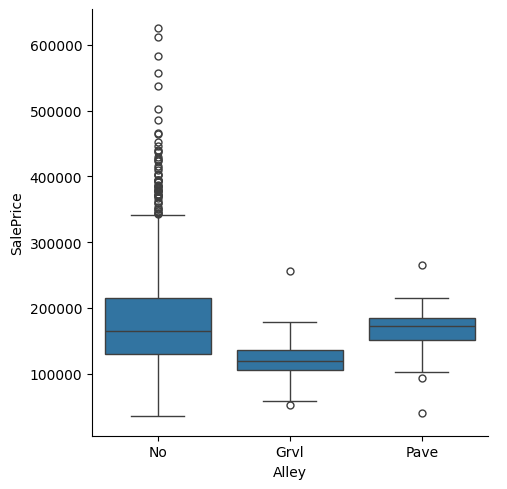

In [354]:
sns.catplot(x='Alley', y='SalePrice', data=housing_data, kind='box')

In [355]:
housing_data['Fence'].unique()     

array([nan, 'MnPrv', 'GdWo', 'GdPrv', 'MnWw'], dtype=object)

In [356]:
housing_data['Fence'].fillna('No' , inplace=True)

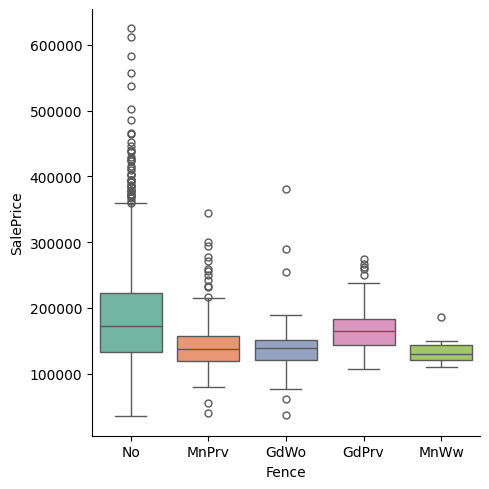

In [357]:
sns.catplot(x='Fence', y='SalePrice',data=housing_data, kind= 'box',palette='Set2')

In [358]:
housing_data['MasVnrType'].unique()

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

In [359]:
housing_data['MasVnrType'].fillna('No', inplace=True)

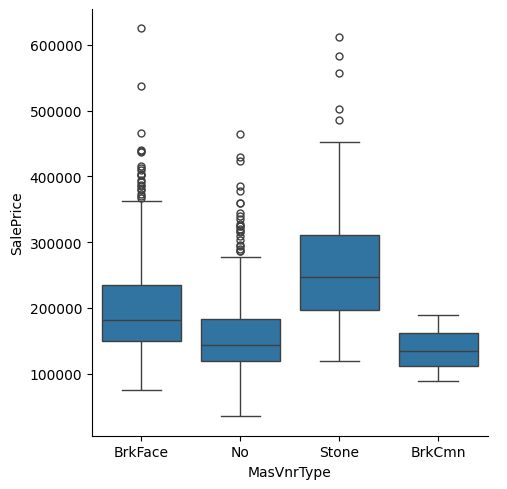

In [360]:
sns.catplot(x='MasVnrType', y='SalePrice', data=housing_data, kind='box')

In [361]:
housing_data['FireplaceQu'].unique()

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [362]:
housing_data['FireplaceQu'].fillna('No', inplace=True)

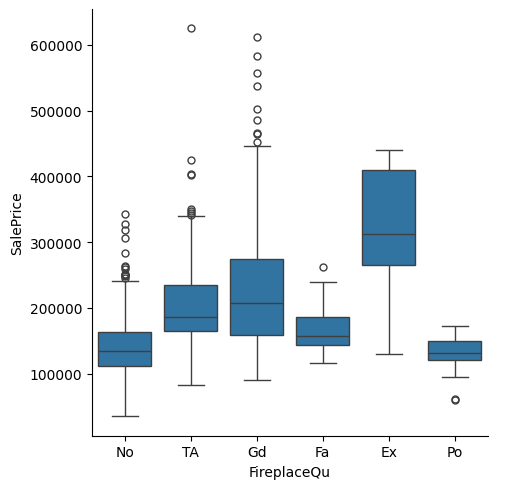

In [363]:
sns.catplot(x='FireplaceQu', y='SalePrice', data=housing_data, kind='box')   

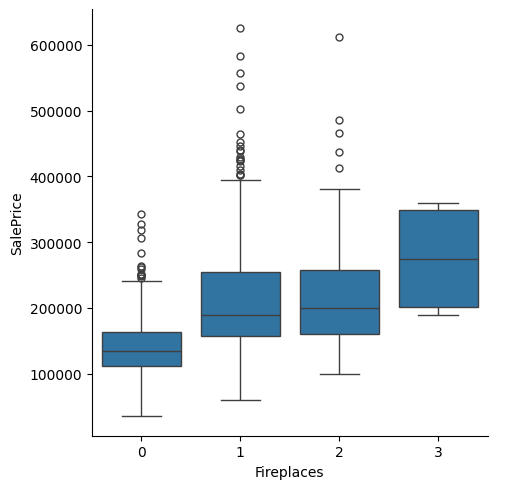

In [364]:
 sns.catplot(x='Fireplaces', y='SalePrice', data=housing_data, kind='box')  

In [365]:
housing_data['LotFrontage'].fillna(0, inplace=True)

In [366]:
housing_data['GarageYrBlt'].corr(housing_data['YearBuilt'])

np.float64(0.8280215065429495)

In [367]:
housing_data['GarageCond'].unique()

array(['TA', 'Fa', nan, 'Gd', 'Po', 'Ex'], dtype=object)

In [368]:
housing_data['GarageCond'].fillna('No', inplace=True)

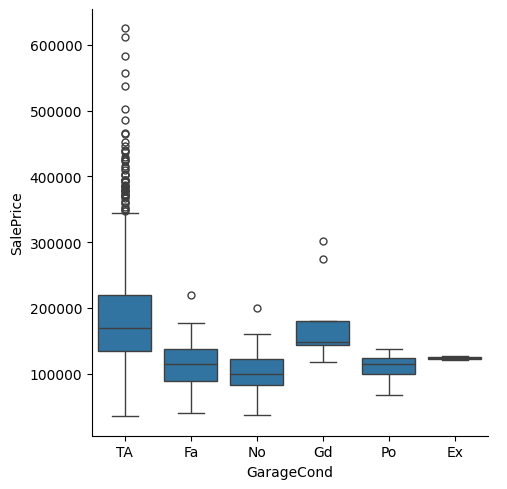

In [369]:
sns.catplot(x='GarageCond', y='SalePrice', data=housing_data, kind='box')

In [370]:
housing_data['GarageType'].fillna('No', inplace=True)

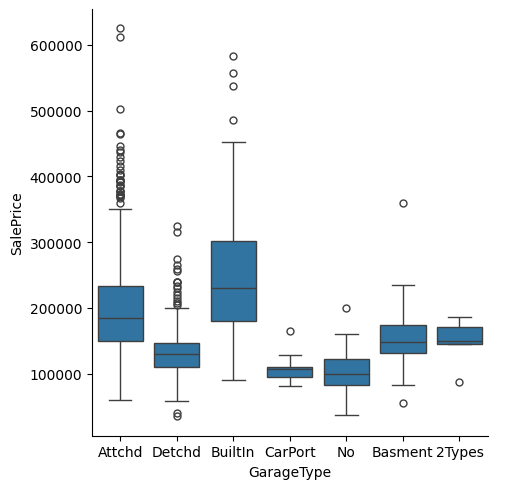

In [371]:
sns.catplot(x='GarageType', y='SalePrice', data=housing_data, kind='box')

In [372]:
housing_data['GarageFinish'].fillna('No', inplace=True)

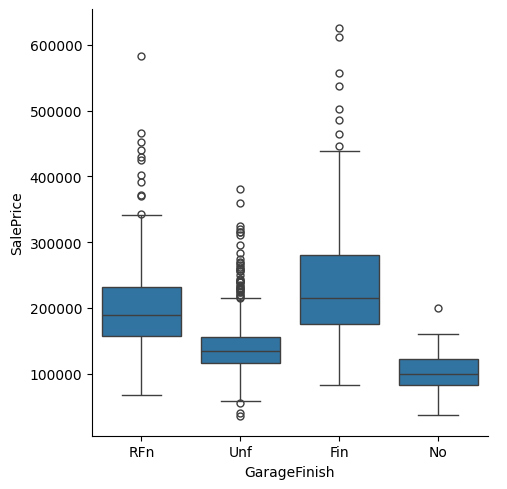

In [373]:
sns.catplot(x='GarageFinish', y='SalePrice', data=housing_data, kind='box')

In [374]:
housing_data['GarageQual'].fillna('No', inplace=True)

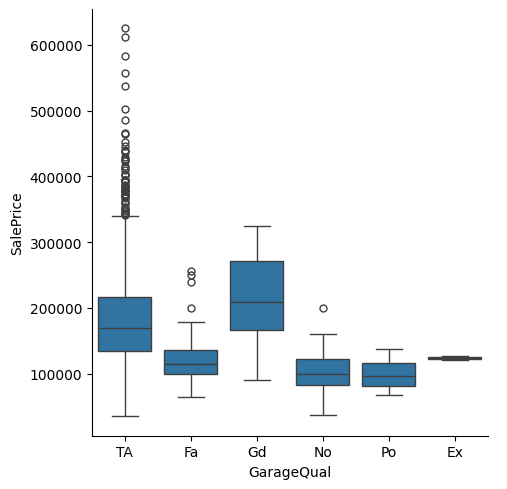

In [375]:
sns.catplot(x='GarageQual', y='SalePrice', data=housing_data, kind='box')

In [376]:
housing_data['BsmtFinType2'].unique()

array(['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

In [377]:
housing_data['BsmtFinType2'].fillna('Unf', inplace=True)

In [378]:
housing_data['BsmtFinType2'].unique()

array(['Unf', 'BLQ', 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

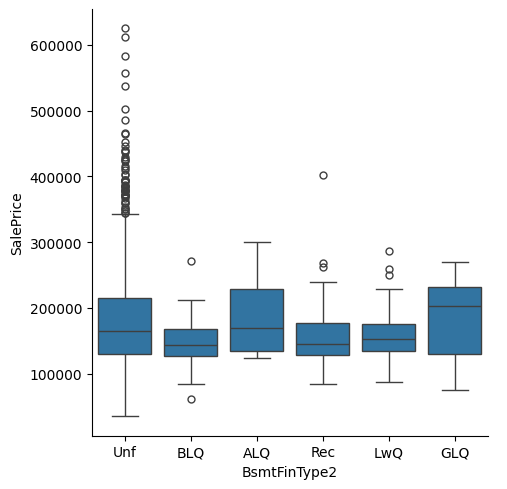

In [379]:
sns.catplot(x='BsmtFinType2', y='SalePrice', data=housing_data, kind='box')

In [380]:
housing_data['BsmtExposure'].unique()

array(['No', 'Gd', 'Mn', 'Av', nan], dtype=object)

In [381]:
housing_data['BsmtExposure'].fillna('Nb', inplace=True)

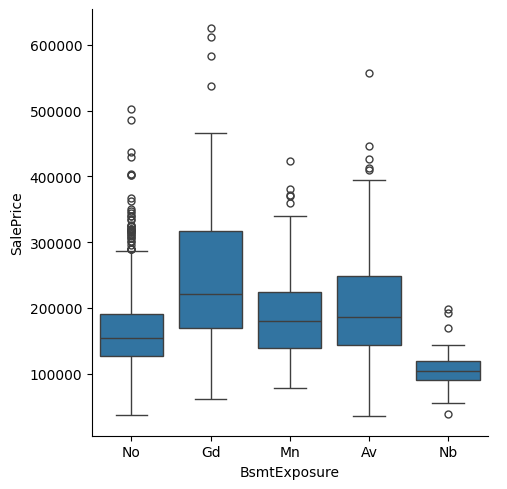

In [382]:
sns.catplot(x='BsmtExposure', y='SalePrice', data=housing_data, kind='box')

In [383]:
housing_data['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

In [384]:
housing_data['BsmtQual'].fillna('No', inplace=True)

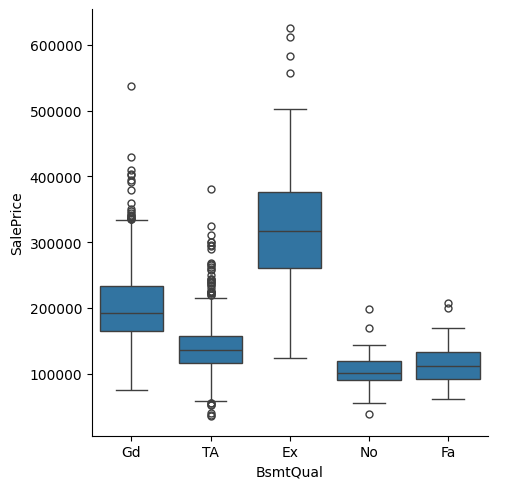

In [385]:
sns.catplot(x='BsmtQual', y='SalePrice', data=housing_data, kind='box')

In [386]:
housing_data['BsmtCond'].unique()

array(['TA', 'Gd', nan, 'Fa', 'Po'], dtype=object)

In [387]:
housing_data['BsmtCond'].fillna('No', inplace=True)

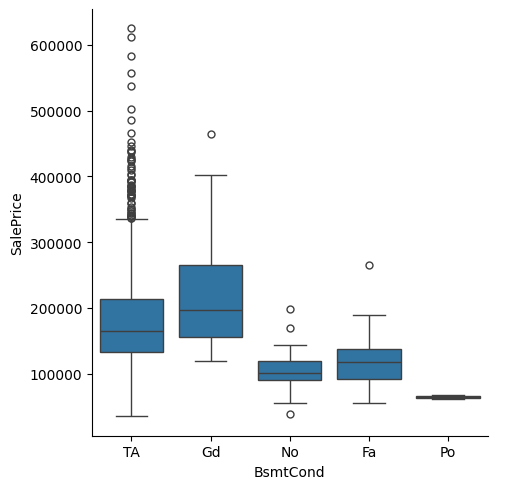

In [388]:
sns.catplot(x='BsmtCond', y='SalePrice', data=housing_data, kind='box')

In [389]:
housing_data['BsmtFinType1'].unique()

array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ'], dtype=object)

In [390]:
housing_data['BsmtFinType1'].fillna('Unf', inplace=True)

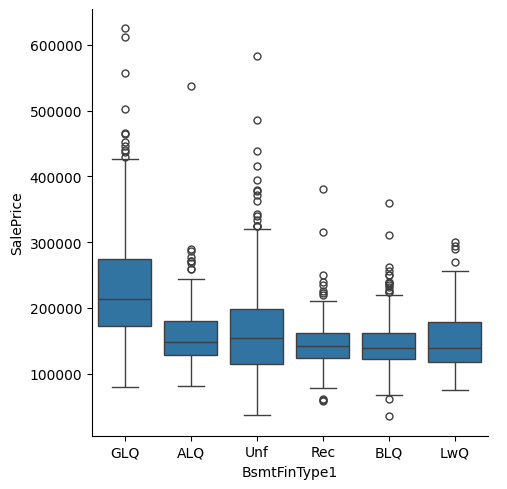

In [391]:
sns.catplot(x='BsmtFinType1', y='SalePrice', data=housing_data, kind='box')

In [392]:
housing_data['MasVnrArea'].fillna(0, inplace=True)

In [393]:
housing_data['Electrical'].fillna('SBrkr', inplace=True)

In [394]:
housing_data = housing_data.drop(
    columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence',
             'GarageYrBlt', 'GarageCond', 'BsmtCond', 'BsmtQual']
)

# Feature engineering

In [395]:
housing_data['housing_age'] = housing_data['YrSold'] - housing_data['YearBuilt'] 

In [396]:
housing_data['houseremodel_age'] = housing_data['YrSold'] - housing_data['YearRemodAdd']

In [397]:
housing_data['totalsf']= housing_data['BsmtFinSF1'] + housing_data['1stFlrSF'] + housing_data['2ndFlrSF']

In [398]:
housing_data['totalarea'] = housing_data['GrLivArea'] + housing_data['TotalBsmtSF']

In [399]:
housing_data['totalbaths'] = housing_data['BsmtFullBath'] + housing_data['FullBath'] + 0.5 * (housing_data['BsmtHalfBath'] + housing_data['HalfBath'])

In [400]:
housing_data['totalporchsf'] = housing_data['OpenPorchSF'] + housing_data['3SsnPorch'] + housing_data['EnclosedPorch'] + housing_data['ScreenPorch'] + housing_data['WoodDeckSF']

In [401]:
print(housing_data.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'SalePrice

In [402]:
housing_data = housing_data.drop(columns=['Id','YrSold','YearBuilt','YearRemodAdd','1stFlrSF','2ndFlrSF','BsmtFinSF1','GrLivArea','TotalBsmtSF','OpenPorchSF','3SsnPorch','EnclosedPorch','ScreenPorch','WoodDeckSF','GarageArea'])

Text(0.5, 1.0, 'Correlation Matrix')

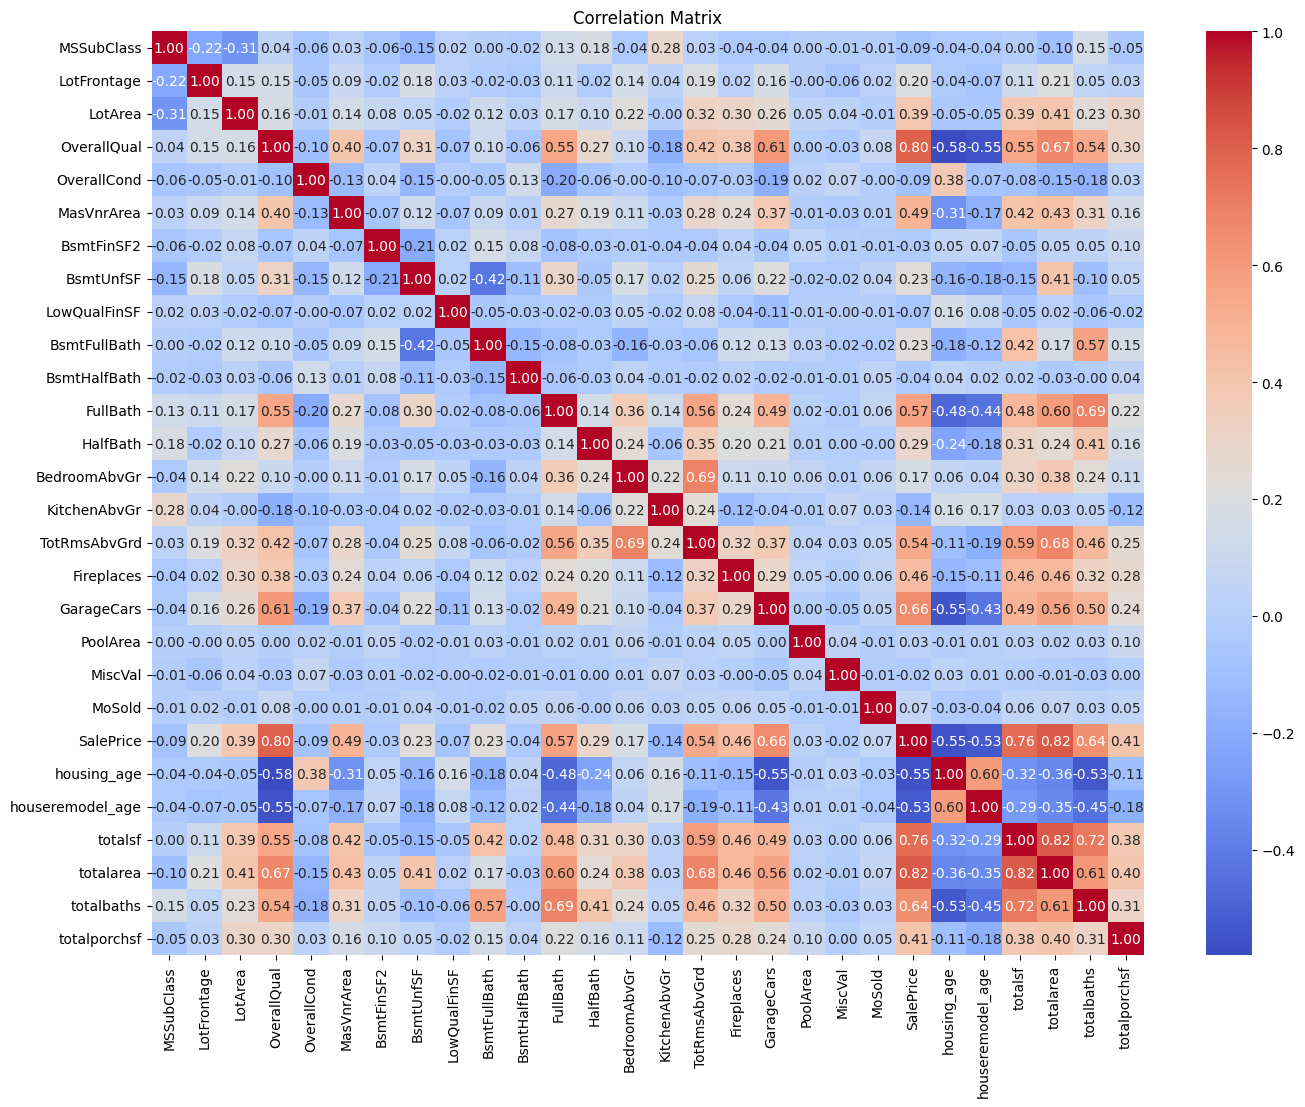

In [403]:
correlation_matrix = housing_data.corr(numeric_only=True)
plt.figure(figsize=(16,12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')

<Axes: xlabel='SalePrice', ylabel='Count'>

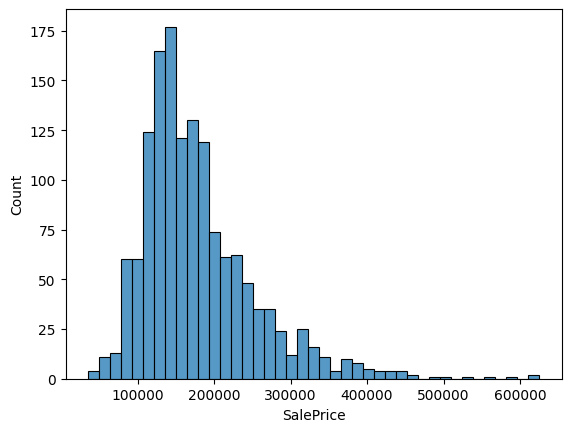

In [404]:
sns.histplot(housing_data,x=housing_data['SalePrice'])

In [405]:
housing_data['SalePrice'] = np.log1p(housing_data['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

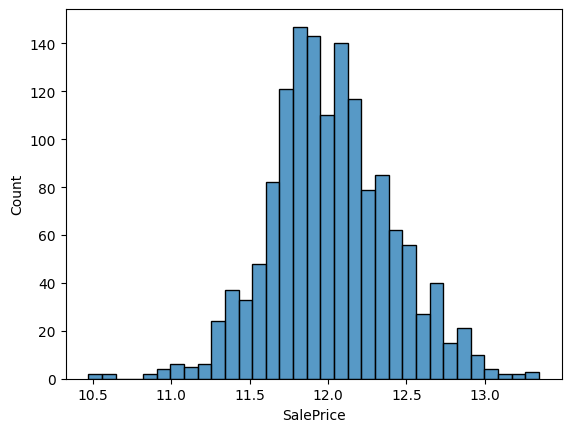

In [406]:
sns.histplot(housing_data,x=housing_data['SalePrice'])

In [407]:
housing_data.dtypes[housing_data.dtypes == 'object']

MSZoning         object
Street           object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
ExterQual        object
ExterCond        object
Foundation       object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Heating          object
HeatingQC        object
CentralAir       object
Electrical       object
KitchenQual      object
Functional       object
FireplaceQu      object
GarageType       object
GarageFinish     object
GarageQual       object
PavedDrive       object
SaleType         object
SaleCondition    object
dtype: object

In [408]:
ode_cols = [
    'ExterQual',
    'ExterCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'HeatingQC',
    'KitchenQual',
    'Functional',
    'FireplaceQu',
    'GarageFinish',
    'GarageQual',
    'PavedDrive'
]


In [409]:
ohe_cols = [
    'MSZoning',
    'Street',
    'LotShape',
    'LandContour',
    'Utilities',
    'LotConfig',
    'LandSlope',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',
    'Foundation',
    'Heating',
    'CentralAir',
    'Electrical',
    'GarageType',
    'SaleType',
    'SaleCondition'
]


In [410]:
assert set(ode_cols).isdisjoint(ohe_cols)
print("ODE & OHE split is correct ✅")


ODE & OHE split is correct ✅


In [411]:
num_cols = housing_data.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('SalePrice')

In [412]:
num_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [413]:
odo_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),   
    ('ode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])


In [414]:
ohe_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),   
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [415]:
col_trans = ColumnTransformer(transformers=[
    ('num_p', num_pipline, num_cols),
    ('ode_p', ohe_pipeline, ode_cols),
    ('ohe_p', odo_pipeline, ohe_cols),
],                      
 remainder='passthrough',
n_jobs=-1)

In [416]:
preprocess_pipelines = Pipeline(
 steps=[('preprocessing', col_trans)]
)

In [417]:
X = housing_data.drop('SalePrice', axis=1)
y = housing_data['SalePrice']

In [418]:
X_preprocessed =preprocess_pipelines.fit_transform(X)

In [419]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

build models

In [420]:
lr = LinearRegression()

In [421]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [422]:
y_pred_lr= lr.predict(X_test)

In [423]:
mean_squared_error(y_test, y_pred_lr)

0.01830168831810948

In [424]:
RFR = RandomForestRegressor(random_state=13)

In [425]:
param_grid_RFR = {
    'max_depth': [5, 10, 15],
    'n_estimators': [100, 250, 500 ],
    'min_samples_split': [3, 5, 10]
}

In [426]:
rfr_cv = GridSearchCV(RFR, param_grid_RFR, cv=5, scoring='neg_mean_squared_error', n_jobs=1)

In [427]:
rfr_cv.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=13)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [3, 5, ...], 'n_estimators': [100, 250, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [428]:
np.sqrt(-1 * rfr_cv.best_score_)

np.float64(0.1338556254373563)

In [429]:
rfr_cv.best_params_

{'max_depth': 15, 'min_samples_split': 3, 'n_estimators': 500}

In [430]:
XGB = XGBRegressor(random_state=13)

In [431]:
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [300],
    'max_depth': [3],
    'min_child_weight': [1,2,3],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

In [432]:
xgb_cv = GridSearchCV(XGB, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=1)

In [433]:
xgb_cv.fit(X_train, y_train)    

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 0.9, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [434]:
np.sqrt(-1 * xgb_cv.best_score_)

np.float64(0.11630967803614457)

In [435]:
ridge = Ridge()

In [436]:
param_grid_ridge = {
    'alpha': [0.05, 0.1, 1, 3, 5, 10],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag']
}

In [437]:
ridge_cv = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=1)

In [438]:
ridge_cv.fit(X_train, y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.05, 0.1, ...], 'solver': ['auto', 'svd', ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,10


In [439]:
np.sqrt(-1 * ridge_cv.best_score_)

np.float64(0.11509043678501363)

In [440]:
GBR = GradientBoostingRegressor()

In [441]:
param_grid_GBR = {
    'max_depth': [12, 15, 20],
    'n_estimators': [200, 300, 1000],
    'min_samples_leaf': [10, 25, 50],
    'learning_rate': [0.001, 0.01, 0.2],
    'max_features': [0.01, 0.1, 0.7]
}    

In [442]:
GBR_cv = GridSearchCV(GBR, param_grid_GBR, cv=5, scoring='neg_mean_squared_error', n_jobs=1)

In [ ]:
GBR_cv.fit(X_train, y_train)

In [ ]:
np.sqrt(-1 * GBR_cv.best_score_)

np.float64(0.11411604735726316)

In [ ]:
lgbm_regressor = lgbm.LGBMRegressor()

In [ ]:
param_grid_ridge = {
    'boosting_type': ['gbdt', 'dart'],
    'num_leaves': [20, 30, 40],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

In [ ]:
lgbm_cv = GridSearchCV(lgbm_regressor, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=1)

In [ ]:
lgbm_cv.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002352 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1954
[LightGBM] [Info] Number of data points in the train set: 918, number of used features: 88
[LightGBM] [Info] Start training from score 12.021014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001677 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1932
[LightGBM] [Info] Number of data points in the train set: 918, number of used features: 88
[LightGBM] [Info] Start training from score 12.008480
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001840 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1938
[LightGBM] [Info] Number of data points in the train set: 

,estimator,LGBMRegressor()
,param_grid,"{'boosting_type': ['gbdt', 'dart'], 'learning_rate': [0.01, 0.05, ...], 'n_estimators': [100, 200, ...], 'num_leaves': [20, 30, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [ ]:
np.sqrt(-1 * lgbm_cv.best_score_)

np.float64(0.12168848649732245)

In [ ]:
vr = VotingRegressor(
    estimators=[
        ('gbr', GBR_cv.best_estimator_),
        ('xgb', xgb_cv.best_estimator_),
        ('ridge', ridge_cv.best_estimator_)
        ],
        weights = [2,3,1]
        )

In [ ]:
vr.fit(X_train,y_train)

,estimators,"[('gbr', ...), ('xgb', ...), ...]"
,weights,"[2, 3, ...]"
,n_jobs,None
,verbose,False
,loss,'squared_error'
,learning_rate,0.01
,n_estimators,1000
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,10


In [ ]:
y_pred_vr = vr.predict(X_test)

In [ ]:
rmse_vr = np.sqrt(mean_squared_error(y_test, y_pred_vr))
rmse_vr


np.float64(0.1216084381001088)

In [ ]:
estimators=[
        ('gbr', GBR_cv.best_estimator_),
        ('xgb', xgb_cv.best_estimator_),
        ('lgbm', lgbm_cv.best_estimator_),
        ('rfr', rfr_cv.best_estimator_),
        ('ridge', ridge_cv.best_estimator_),
        ]   

In [ ]:
Stackreg = StackingRegressor(
    estimators = estimators,
    final_estimator = vr
)

In [ ]:
Stackreg.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2064
[LightGBM] [Info] Number of data points in the train set: 1148, number of used features: 90
[LightGBM] [Info] Start training from score 12.015147
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001004 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1954
[LightGBM] [Info] Number of data points in the train set: 918, number of used features: 88
[LightGBM] [Info] Start training from score 12.021014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001338 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1932
[LightGBM] [Info] Number of data points in the train set: 918, number of used features: 88
[LightGBM] [Info] Start traini

,estimators,"[('gbr', ...), ('xgb', ...), ...]"
,final_estimator,"VotingRegress...hts=[2, 3, 1])"
,cv,None
,n_jobs,None
,passthrough,False
,verbose,0
,loss,'squared_error'
,learning_rate,0.01
,n_estimators,1000
,subsample,1.0
,criterion,'friedman_mse'


In [ ]:
y_pred_stack = Stackreg.predict(X_test)

In [ ]:
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
rmse_stack


np.float64(0.1253884436266306)

In [ ]:
X_preprocessed.shape


(1435, 112)

In [ ]:
housing_data_preprocess = preprocess_pipelines.transform(housing_data)

ValueError: columns are missing: {'totalarea', 'houseremodel_age', 'totalsf', 'housing_age'}

In [ ]:
y_stacking = np.exp(Stackreg.predict(housing_data_preprocess))

In [ ]:
y_stacking_out = housing_data[['Id']].copy()
y_stacking_out['SalePrice'] = y_stacking
y_stacking_out.to_csv('house_price_prediction_stacking.csv', index=False)


